# Chapter 138 — Subspaces

> **Prerequisites:** ch137 (Vector Spaces), ch125 (Vector Addition), ch126 (Scalar Multiplication), ch127 (Linear Combination)  
> **You will learn:**
> - What makes a subset of a vector space a subspace
> - The three closure conditions and why all three are necessary
> - How to verify or falsify subspace membership
> - The most important subspaces: column space, null space, row space
> - Why subspaces are the natural habitat of linear algebra

---

## 1. Concept

A **subspace** is a subset of a vector space that is itself a vector space under the same operations.

Not every subset qualifies. The subset must be *closed under the operations that define the space* — addition and scalar multiplication. If you take two vectors from the subset and add them, you must stay inside the subset. If you scale a vector from the subset, you must stay inside.

The intuition: a subspace is a *flat structure passing through the origin*. Lines through the origin, planes through the origin, the origin itself — these are subspaces of ℝⁿ. A circle, a line not through the origin, a sphere — none of these are subspaces.

**Common misconception:** Every subset containing the origin is a subspace. False. A circle centered at the origin contains the origin but is not closed under addition.

## 2. Intuition & Mental Models

**Geometric analogy:** Think of a subspace as a flat shadow. In 3D space, a plane through the origin is a 2D subspace. A line through the origin is a 1D subspace. The origin alone is a 0D subspace. The full 3D space is a 3D subspace. Every subspace of ℝ³ is one of these four types.

**Computational analogy:** Think of a subspace as the set of all outputs of a linear function from some smaller space. If you have a matrix A with 2 columns in ℝ³, then all vectors of the form Ax (for any x ∈ ℝ²) form a subspace of ℝ³ — specifically a plane (or line, or point) through the origin.

**Closure mental model:** A subspace is *sealed under linear operations*. Any linear combination of vectors inside the subspace stays inside. This is why the origin must always be included — scaling any vector by zero gives the zero vector.

Recall from ch137 that a vector space requires 8 axioms. A subspace inherits all of them from the parent space — you only need to verify 3 conditions.

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_17240\268115826.py:80: UserWarning: Glyph 8477 (\N{DOUBLE-STRUCK CAPITAL R}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_17240\268115826.py:80: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_17240\268115826.py:80: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_17240\268115826.py:80: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_17240\268115826.py:80: UserWarning: Glyph 8713 (\N{NOT AN ELEMENT OF}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8477 (\N{DOUBLE-STRUCK CAPITAL R}) missing from font(s) Arial.
  fig.canvas.print

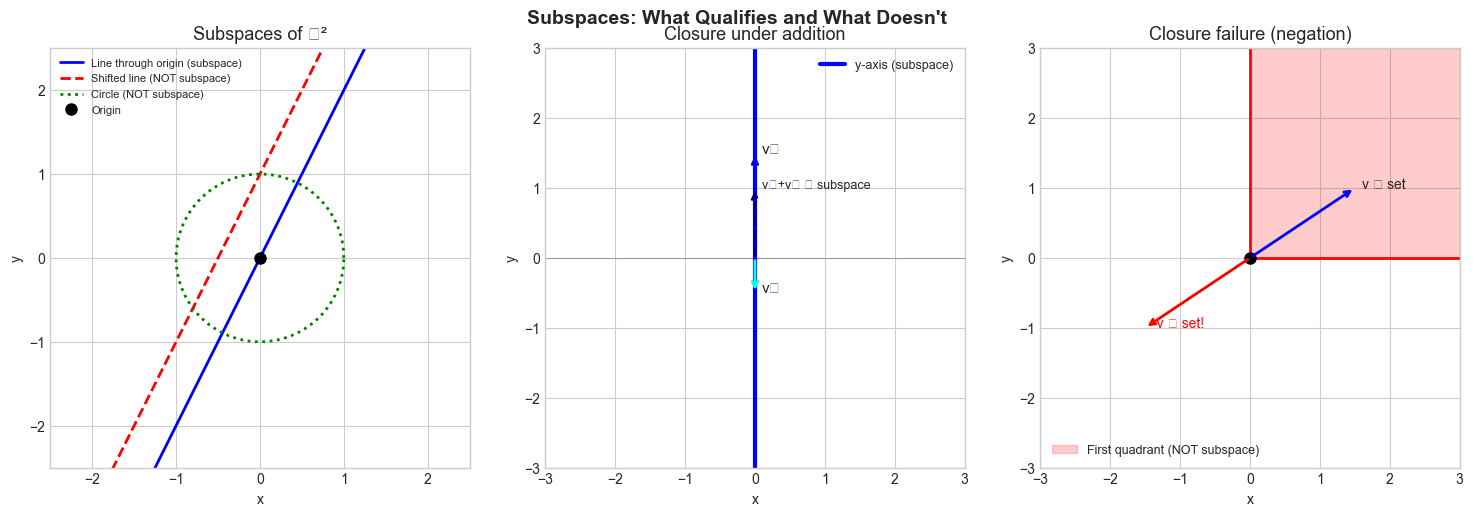

In [1]:
# --- Visualization: Subspaces of R^2 and R^3 ---
# Shows which geometric objects are subspaces (pass through origin, flat)
# and which are not (shifted, curved)

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Plot 1: R^2 subspaces ---
ax = axes[0]
t = np.linspace(-2, 2, 100)

# Subspace: line through origin (y = 2x)
ax.plot(t, 2*t, 'b-', linewidth=2, label='Line through origin (subspace)')

# Non-subspace: line NOT through origin (y = 2x + 1)
ax.plot(t, 2*t + 1, 'r--', linewidth=2, label='Shifted line (NOT subspace)')

# Non-subspace: circle
theta = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(theta), np.sin(theta), 'g:', linewidth=2, label='Circle (NOT subspace)')

ax.plot(0, 0, 'ko', markersize=8, label='Origin')
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal')
ax.set_title('Subspaces of ℝ²', fontsize=13)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(fontsize=8)

# --- Plot 2: Closure test visualization ---
ax2 = axes[1]
ax2.set_xlim(-3, 3); ax2.set_ylim(-3, 3)
ax2.set_aspect('equal')
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.axvline(0, color='gray', linewidth=0.5)

# Subspace: the y-axis (all vectors [0, y])
ax2.plot([0, 0], [-3, 3], 'b-', linewidth=3, label='y-axis (subspace)')

# Demonstrate closure: two vectors in y-axis
v1 = np.array([0, 1.5])
v2 = np.array([0, -0.5])
v_sum = v1 + v2
ax2.annotate('', xy=v1, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax2.annotate('', xy=v2, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='cyan', lw=2))
ax2.annotate('', xy=v_sum, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='navy', lw=2, linestyle='dashed'))
ax2.text(0.1, 1.5, 'v₁', fontsize=11); ax2.text(0.1, -0.5, 'v₂', fontsize=11)
ax2.text(0.1, v_sum[1], 'v₁+v₂ ∈ subspace', fontsize=9)
ax2.set_title('Closure under addition', fontsize=13)
ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.legend(fontsize=9)

# --- Plot 3: Failure of closure ---
ax3 = axes[2]
ax3.set_xlim(-3, 3); ax3.set_ylim(-3, 3)
ax3.set_aspect('equal')

# Non-subspace: first quadrant (not closed under negation)
x_fill = np.array([0, 3, 3, 0])
y_fill = np.array([0, 0, 3, 3])
ax3.fill(x_fill, y_fill, alpha=0.2, color='red', label='First quadrant (NOT subspace)')
ax3.plot([0, 3], [0, 0], 'r-', lw=2)
ax3.plot([0, 0], [0, 3], 'r-', lw=2)

v = np.array([1.5, 1.0])
neg_v = -v
ax3.annotate('', xy=v, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax3.annotate('', xy=neg_v, xytext=[0,0], arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax3.text(v[0]+0.1, v[1], 'v ∈ set', fontsize=10)
ax3.text(neg_v[0]+0.1, neg_v[1], '-v ∉ set!', fontsize=10, color='red')
ax3.plot(0, 0, 'ko', markersize=8)
ax3.set_title('Closure failure (negation)', fontsize=13)
ax3.set_xlabel('x'); ax3.set_ylabel('y')
ax3.legend(fontsize=9)

plt.suptitle('Subspaces: What Qualifies and What Doesn\'t', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

Let V be a vector space. A subset W ⊆ V is a **subspace** if and only if:

**S1 — Contains zero:** 0 ∈ W  
**S2 — Closed under addition:** For all u, v ∈ W: u + v ∈ W  
**S3 — Closed under scalar multiplication:** For all v ∈ W, c ∈ ℝ: cv ∈ W  

Note: S1 follows from S3 (set c = 0), so in practice you only need S2 and S3. But stating S1 explicitly is useful as a quick filter.

**Equivalently (single condition):** W is a subspace iff it is closed under linear combinations:

For all u, v ∈ W and scalars a, b: au + bv ∈ W

**Key subspaces of a matrix A (m×n):**
- **Column space** C(A): span of columns of A, a subspace of ℝᵐ
- **Null space** N(A): all x such that Ax = 0, a subspace of ℝⁿ
- **Row space** C(Aᵀ): span of rows of A, a subspace of ℝⁿ
- **Left null space** N(Aᵀ): all y such that Aᵀy = 0, a subspace of ℝᵐ

## 5. Python Implementation

In [2]:
# --- Implementation: Subspace verification and fundamental subspaces ---
import numpy as np

def is_closed_under_addition(vectors, test_pairs=50, atol=1e-10):
    """
    Test closure under addition for a set of vectors.
    
    Strategy: sample random linear combinations and check membership
    (membership approximated by checking if the projection residual is near zero).
    
    Args:
        vectors: array of shape (n_vecs, dim) spanning the candidate subspace
        test_pairs: number of random pairs to test
        atol: tolerance for membership check
    
    Returns:
        bool: True if closure appears to hold
    """
    n = len(vectors)
    rng = np.random.default_rng(42)
    
    for _ in range(test_pairs):
        # Pick two random vectors from the span
        c1 = rng.standard_normal(n)
        c2 = rng.standard_normal(n)
        v1 = vectors.T @ c1
        v2 = vectors.T @ c2
        v_sum = v1 + v2
        
        # Check if v_sum is in the span of vectors
        # Project v_sum onto span(vectors) and check residual
        V = vectors.T  # columns are basis vectors
        # Solve least squares: V @ x ≈ v_sum
        x, residuals, rank, sv = np.linalg.lstsq(V, v_sum, rcond=None)
        projection = V @ x
        residual = np.linalg.norm(v_sum - projection)
        
        if residual > atol:
            return False
    return True


def column_space_basis(A, tol=1e-10):
    """
    Compute an orthonormal basis for the column space of A.
    Uses QR decomposition with column pivoting.
    
    Args:
        A: matrix of shape (m, n)
        tol: threshold for detecting zero singular values
    
    Returns:
        basis: array of shape (m, r) where r = rank(A)
    """
    # SVD gives the most numerically stable basis
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    rank = np.sum(s > tol)
    return U[:, :rank]  # columns of U span the column space


def null_space_basis(A, tol=1e-10):
    """
    Compute an orthonormal basis for the null space of A.
    The null space: all x such that Ax = 0.
    
    Args:
        A: matrix of shape (m, n)
        tol: threshold
    
    Returns:
        basis: array of shape (n, (n - rank)) or empty if trivial
    """
    U, s, Vt = np.linalg.svd(A, full_matrices=True)
    rank = np.sum(s > tol)
    # The last (n - rank) rows of Vt span the null space
    null_basis = Vt[rank:].T  # shape (n, n-rank)
    return null_basis


def verify_null_space(A, null_basis, atol=1e-10):
    """
    Verify: every column of null_basis satisfies Ax = 0.
    """
    for i in range(null_basis.shape[1]):
        x = null_basis[:, i]
        residual = np.linalg.norm(A @ x)
        if residual > atol:
            return False, i, residual
    return True, -1, 0.0


# --- Example: Find subspaces of a 3x4 matrix ---
np.random.seed(7)
A = np.array([
    [1, 2, 0, 1],
    [2, 4, 1, 3],
    [0, 0, 1, 1]
], dtype=float)

print(f"Matrix A ({A.shape[0]}x{A.shape[1]}):")
print(A)
print()

col_basis = column_space_basis(A)
nul_basis = null_space_basis(A)
rank = col_basis.shape[1]
nullity = nul_basis.shape[1] if nul_basis.size > 0 else 0

print(f"Rank (dimension of column space): {rank}")
print(f"Nullity (dimension of null space): {nullity}")
print(f"Rank + Nullity = {rank + nullity} = n = {A.shape[1]}  ← Rank-Nullity Theorem")
print()
print("Column space basis (orthonormal):")
print(np.round(col_basis, 4))
print()
print("Null space basis:")
print(np.round(nul_basis, 4))

ok, idx, res = verify_null_space(A, nul_basis)
print(f"\nNull space verification: A @ null_basis ≈ 0? {ok}")

Matrix A (3x4):
[[1. 2. 0. 1.]
 [2. 4. 1. 3.]
 [0. 0. 1. 1.]]

Rank (dimension of column space): 2
Nullity (dimension of null space): 2
Rank + Nullity = 4 = n = 4  ← Rank-Nullity Theorem

Column space basis (orthonormal):
[[ 0.3962  0.42  ]
 [ 0.9105 -0.0653]
 [ 0.1182 -0.9052]]

Null space basis:
[[-0.8746  0.2307]
 [ 0.3037 -0.4248]
 [-0.2672 -0.619 ]
 [ 0.2672  0.619 ]]

Null space verification: A @ null_basis ≈ 0? True


## 6. Experiments

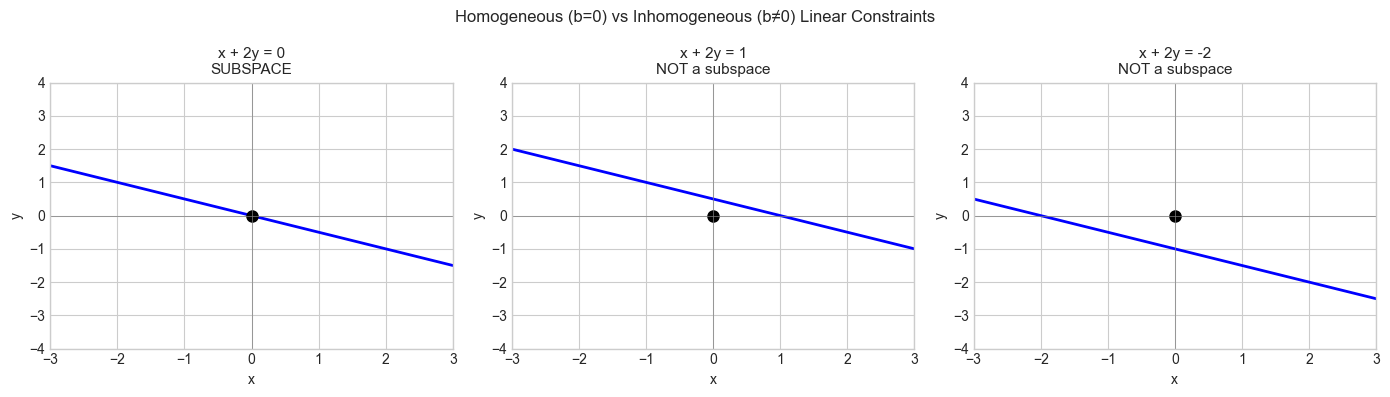

Observation: only the line through the origin is a subspace.


In [3]:
# --- Experiment 1: Which sets are subspaces? ---
# Hypothesis: A set defined by a homogeneous linear condition is a subspace;
# a set defined by an inhomogeneous condition is not.

import numpy as np

def sample_from_hyperplane(a, b, n=200):
    """
    Sample vectors from {x in R^2 : a^T x = b}.
    When b=0 this is a subspace; when b≠0 it is an affine subspace (not a subspace).
    """
    # Parametrize: for x1 free, x2 = (b - a[0]*x1) / a[1]
    x1 = np.linspace(-3, 3, n)
    x2 = (b - a[0] * x1) / a[1]
    return np.column_stack([x1, x2])

a = np.array([1.0, 2.0])
B_values = [0, 1, -2]  # <-- modify: try different values of b

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, b in zip(axes, B_values):
    pts = sample_from_hyperplane(a, b)
    ax.plot(pts[:, 0], pts[:, 1], 'b-', lw=2)
    ax.plot(0, 0, 'ko', markersize=8)
    contains_origin = abs(a @ np.array([0, 0]) - b) < 1e-10
    is_sub = "SUBSPACE" if contains_origin else "NOT a subspace"
    ax.set_title(f'x + 2y = {b}\n{is_sub}', fontsize=11)
    ax.set_xlim(-3, 3); ax.set_ylim(-4, 4)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)

plt.suptitle('Homogeneous (b=0) vs Inhomogeneous (b≠0) Linear Constraints', fontsize=12)
plt.tight_layout(); plt.show()
print("Observation: only the line through the origin is a subspace.")

In [4]:
# --- Experiment 2: Rank-Nullity Theorem ---
# Hypothesis: For any m×n matrix, rank + nullity = n always.
# Try changing: matrix dimensions, rank, entries

import numpy as np

def check_rank_nullity(m, n, target_rank=None):
    rng = np.random.default_rng(0)
    if target_rank is None:
        target_rank = min(m, n)
    # Build a rank-deficient matrix: A = U @ V where U is m×r, V is r×n
    U = rng.standard_normal((m, target_rank))
    V = rng.standard_normal((target_rank, n))
    A = U @ V
    
    col_basis = column_space_basis(A)
    nul_basis = null_space_basis(A)
    rank = col_basis.shape[1]
    nullity = nul_basis.shape[1] if nul_basis.size > 0 else 0
    
    print(f"  Matrix {m}×{n}, target_rank={target_rank}: rank={rank}, nullity={nullity}, "
          f"rank+nullity={rank+nullity} (n={n}) ✓" if rank+nullity==n else " MISMATCH")

print("Rank-Nullity checks:")
for m, n, r in [(3, 5, 2), (4, 4, 3), (2, 6, 1), (5, 3, 3)]:  # <-- modify these
    check_rank_nullity(m, n, target_rank=r)

Rank-Nullity checks:
  Matrix 3×5, target_rank=2: rank=2, nullity=3, rank+nullity=5 (n=5) ✓
  Matrix 4×4, target_rank=3: rank=3, nullity=1, rank+nullity=4 (n=4) ✓
  Matrix 2×6, target_rank=1: rank=1, nullity=5, rank+nullity=6 (n=6) ✓
  Matrix 5×3, target_rank=3: rank=3, nullity=0, rank+nullity=3 (n=3) ✓


In [5]:
# --- Experiment 3: Intersection of subspaces ---
# Hypothesis: The intersection of two subspaces is always a subspace.
# Two planes through the origin in R^3 intersect in a line (also through origin).

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Plane 1: normal n1 = [1, 0, 0]  → the y-z plane (x=0)
# Plane 2: normal n2 = [0, 1, 0]  → the x-z plane (y=0)
# Intersection: x=0 AND y=0 → the z-axis

n1 = np.array([1.0, 0, 0])  # <-- modify: change the normal vectors
n2 = np.array([0.0, 1, 0])

# Intersection direction = n1 × n2
intersection_dir = np.cross(n1, n2)
if np.linalg.norm(intersection_dir) < 1e-10:
    print("Planes are parallel (or identical) — intersection is a plane or empty")
else:
    intersection_dir = intersection_dir / np.linalg.norm(intersection_dir)
    print(f"Plane 1 normal: {n1}")
    print(f"Plane 2 normal: {n2}")
    print(f"Intersection direction (line through origin): {np.round(intersection_dir, 4)}")
    print("Verify: n1 · dir =", np.dot(n1, intersection_dir).round(10), "(should be 0)")
    print("Verify: n2 · dir =", np.dot(n2, intersection_dir).round(10), "(should be 0)")

Plane 1 normal: [1. 0. 0.]
Plane 2 normal: [0. 1. 0.]
Intersection direction (line through origin): [0. 0. 1.]
Verify: n1 · dir = 0.0 (should be 0)
Verify: n2 · dir = 0.0 (should be 0)


## 7. Exercises

**Easy 1.** Show that the set W = {(x, y) ∈ ℝ² : y = 3x} is a subspace by verifying all three conditions. *(Expected: manual verification with examples)*

**Easy 2.** The set S = {(x, y) ∈ ℝ² : xy = 0} (the two coordinate axes) contains the origin and is closed under scalar multiplication. Show that it is NOT a subspace by finding two vectors in S whose sum is not in S. *(Expected: a counterexample)*

**Medium 1.** Write a function `is_subspace_of_Rn(vectors, candidate)` that takes a matrix `vectors` (whose columns span a subspace W) and a vector `candidate`, and tests whether `candidate` lies in W. Test it on the column space and null space of a matrix you construct. *(Hint: use least squares projection and check the residual)*

**Medium 2.** Construct a 4×6 matrix of rank 2. Compute its column space, null space, row space, and left null space. Verify: dim(C(A)) + dim(N(Aᵀ)) = m, and dim(C(Aᵀ)) + dim(N(A)) = n. *(Coding task)*

**Hard.** Prove algebraically that the intersection of two subspaces W₁ and W₂ of a vector space V is always a subspace. Then implement a function that, given two sets of basis vectors for W₁ and W₂ in ℝⁿ, computes a basis for their intersection. *(Challenge: the computation requires solving a system of the form [A | -B]x = 0)*

## 8. Mini Project

In [ ]:
# --- Mini Project: Constraint Satisfier via Null Space ---
#
# Problem: In robotics and physics, you often have a system with constraints.
# Given a robot arm with n joints, subject to m linear constraints (Ax = b),
# the space of solutions is an affine subspace: one particular solution + null space of A.
#
# This is also how linear systems work: the general solution to Ax = b
# is x = x_particular + x_null, where x_null ∈ N(A).
#
# Task: Given a constraint matrix A and target b, find the general solution space
# and visualize the solution set.

import numpy as np
import matplotlib.pyplot as plt

# Constraint: 2x + y = 5 (1 equation, 2 unknowns → 1D solution space)
A = np.array([[2.0, 1.0]])
b = np.array([5.0])

# Step 1: Find a particular solution (minimum norm solution via pseudoinverse)
x_particular = np.linalg.lstsq(A, b, rcond=None)[0]
print(f"Particular solution: x_p = {x_particular}")
print(f"Verify Ax_p = b: {A @ x_particular} (should be {b})")

# Step 2: Find null space basis
null_basis = null_space_basis(A)
print(f"\nNull space basis:\n{null_basis}")
print(f"Null space dimension: {null_basis.shape[1]} (rank-nullity: n=2, rank=1)")

# Step 3: General solution = x_particular + t * null_basis[:,0]
t_values = np.linspace(-4, 4, 100)
solutions = x_particular[:, None] + null_basis @ (t_values[None, :])  # shape (2, 100)

# Verify all solutions satisfy the constraint
residuals = A @ solutions - b[:, None]
print(f"\nMax constraint violation over all solutions: {np.max(np.abs(residuals)):.2e}")

# Step 4: Visualize
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(solutions[0], solutions[1], 'b-', lw=2, label='Solution set (affine subspace)')
ax.plot(*x_particular, 'ro', markersize=10, label='Particular solution (min norm)')
ax.annotate('', xy=x_particular + null_basis[:, 0], xytext=x_particular,
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(*(x_particular + null_basis[:, 0] + 0.1), 'null space\ndirection', fontsize=10, color='green')
ax.plot(0, 0, 'ks', markersize=8, label='Origin')
ax.set_xlim(-4, 6); ax.set_ylim(-4, 6)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.set_title('General solution to 2x₁ + x₂ = 5\n= particular solution + null space', fontsize=12)
ax.legend(); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

# TODO: Try a 2-equation, 3-unknown system (solution is a line in R^3)
# TODO: Visualize the null space shifting with different b values

## 9. Chapter Summary & Connections

**What was covered:**
- A subspace is a subset closed under addition, scalar multiplication, and containing the zero vector.
- The three closure conditions are necessary; failing any one disqualifies the set.
- Every matrix defines four fundamental subspaces: column space, null space, row space, left null space.
- The Rank-Nullity Theorem: rank(A) + nullity(A) = n (number of columns).
- The general solution to Ax = b is a particular solution plus the null space — an affine subspace.

**Backward connection:** The notion of closure generalizes ch137's vector space axioms — subspaces inherit all 8 axioms from the parent space.

**Forward connections:**
- Subspaces are the foundation for ch139 (Basis and Dimension) — a basis is a minimal spanning set for a subspace.
- The four fundamental subspaces reappear throughout ch151–200 (Linear Algebra), especially in ch165 (Systems of Linear Equations) and ch166 (Gaussian Elimination).
- The null space is central to ch183 (Eigenvalue Computation): eigenvectors are elements of the null space of (A − λI).

**Going deeper:** Gilbert Strang's *Introduction to Linear Algebra* devotes its first four chapters to the four fundamental subspaces — highly recommended as a companion read to Part VI.